## _4.1.1. (binary) Classification using GMM (Gaussian Mixture Model )_

This is the main topics of the current notebook. We will focus on applying GMM to the problem of anomaly detection in two cases. 

- The first, detecting normal/abnormal samples whatever the anomaly degree of the case is.

- The second, we concerve only the samples tagged as highly affected with anomaly, i.e. 50% of packet affected


#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
%matplotlib inline

In [2]:
import seaborn as sns 
import plotly.express as px
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors

In [3]:
import torch
import os

import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [4]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(5)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0
2,-1.582333,-0.436192,-0.186196,-0.164204,-1.108483,0.193475,-0.664977,-0.665158,-0.460461,-0.978685,...,0.367256,-1.462647,0.524565,-0.964049,-0.045817,bad,0,-1.083746,False,0
3,-1.524596,-0.430804,-0.169590,-0.164204,-0.826439,0.384235,-0.245217,-0.244990,-0.363067,-0.799582,...,0.378520,-1.462647,0.524565,-0.956997,-0.045817,bad,0,-1.083746,False,0
4,-1.466860,-0.425614,-0.169846,-0.164204,-0.422082,0.397624,-0.242853,-0.242699,-0.259859,-0.665255,...,0.394329,-1.462647,0.524565,-0.943719,-0.045817,bad,0,-1.083746,False,0


In [5]:
# Recall, all the following have been deleted --> ['Seg_Dur', 'Codec', 'FPS', 'Protocol']
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level', 'Width',
                'Height', 'Play_Pos', 'RTT', 'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']

new_df = scaled_new_df [all_features]
selected_features = all_features[:-4]
target = "tag2"

In [6]:
dataset_name = 'new_godash_dataset'
train = new_df.copy()
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


#### _b. Label Encode target y_

###### (normal vs abnormal)

The basic Idea here is to see the problem as a binary classification problem. 

The population is already devided into _normal_ and _abnormal_

In [7]:
train[target].value_counts(normalize=True)

True     0.746951
False    0.253049
Name: tag2, dtype: float64

#### _c. Split_

In [8]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices =    train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'tag', 'level', 'anomaly']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

print ("len(features) =", len(features))

if os.getenv("CI", False):
# Take only a subsample to run CI
    X_train = train[features].values[train_indices][:1000,:]
    y_train = train[target].values[train_indices][:1000]
else:
    X_train = train[features].values[train_indices]
    y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("shape(X_train) :", X_train.shape)
print ("shape(y_train) :", y_train.shape)

len(features) = 22
shape(X_train) : (45650, 22)
shape(y_train) : (45650,)


#### _d. Check CUDA support_

In [9]:
torch.cuda.is_available()

True

In [10]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

### _e.  Gaussian mixture models for anomaly detection (case a)_

- _**Gaussian mixture models**_ are a probabilistic model for representing normally distributed subpopulations within an overall population. 

- Mixture models in general don't require knowing which subpopulation a data point belongs to, allowing the model to learn the subpopulations automatically. 

<br>

<div style="float: center;"><img  src="https://nixustechnologies.com/wp-content/uploads/2022/06/gaussian-distribution-model.webp"  alt="binary classification"  width="250"/>
</div>

</br>




Since subpopulation assignment is not known, this constitutes a form of unsupervised learning [[src]](https://brilliant.org/wiki/gaussian-mixture-model/).

We will use _**sklearn.mixture.GaussianMixture**_, an implementation of GMM available on _**scikit-learn**_ at [[sklearn.mixture.GaussianMixture]](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html)

In [11]:
gmm = GaussianMixture(n_components=2, random_state=42)  # Assuming 2 components, one for normal and one for anomaly
gmm.fit(X_train)

GaussianMixture(n_components=2, random_state=42)

In [12]:
# Predict probabilities for each sample
probs = gmm.score_samples(X_valid)

# Choose a range of thresholds to try
thresholds = np.linspace(min(probs), max(probs), 1000)

best_threshold = None
best_accuracy = 0

for threshold in thresholds:
    # Classify samples as anomalies based on the threshold
    y_pred = (probs < threshold).astype(int)

    # Calculate accuracy
    accuracy = accuracy_score(y_valid, y_pred)

    # Update best threshold if the current one gives a higher accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = threshold

# Use the best threshold for anomaly detection
y_anomaly = (probs < best_threshold).astype(int)

# Print the best threshold and accuracy
print(f"Best Threshold: {best_threshold}")
print(f"Best (validation) Accuracy: {best_accuracy * 100:.2f}%")
# print("Classification Report:")
# print(classification_report(y_valid, y_anomaly))

Best Threshold: 45.16725740171872
Best (validation) Accuracy: 74.45%


Final evaluation of our model, using _**test set**_ :

In [13]:
# Train the GMM model on the training set
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_train)

# Predict probabilities for each sample in the test set
probs_test = gmm.score_samples(X_test)

# Use the best threshold for anomaly detection on the test set
y_anomaly_test = (probs_test < best_threshold).astype(int)

# Print the best threshold and accuracy on the test set
accuracy_test = accuracy_score(y_test, y_anomaly_test)
print(f"Calculated Best Threshold is : {best_threshold}")
print(f"Accuracy on Test Set: {accuracy_test * 100:.2f}%")

# Print classification report and confusion matrix on the test set
print("\n Classification Report on Test Set:")
print(classification_report(y_test, y_anomaly_test))

Calculated Best Threshold is : 45.16725740171872
Accuracy on Test Set: 74.77%

 Classification Report on Test Set:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00      4319
        True       0.75      1.00      0.86     12801

    accuracy                           0.75     17120
   macro avg       0.37      0.50      0.43     17120
weighted avg       0.56      0.75      0.64     17120



C:\Users\kabou\.conda\envs\py37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kabou\.conda\envs\py37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kabou\.conda\envs\py37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [14]:
f1 = f1_score(y_test, y_anomaly_test)
print(f"F1-Score: {f1 * 100:.2f}%")
recall = recall_score(y_test, y_anomaly_test)
print(f"Recall: {recall * 100:.2f}%")

precision = precision_score(y_test, y_anomaly_test)
print(f"Precision: {precision * 100:.2f}%")

F1-Score: 85.57%
Recall: 100.00%
Precision: 74.77%


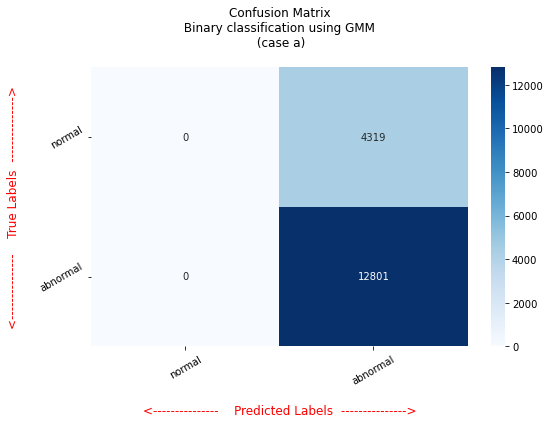

In [15]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_anomaly_test)

labeled_classes = ['normal', 'abnormal']
classes = [0+0.5, 1+0.5]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title("Confusion Matrix\n Binary classification using GMM \n (case a)\n")
plt.tight_layout()
plt.show()

### _(Case b) : taking into consideration hight anomalies only_

The basic Idea here is not just to detect the fact that this is a anomaly situation, but to detect the nature of anomaly.

The problem now is not a binary but a _**multiclass**_ classification. We start by targeting the hight anomalies (50%).

This results in the following four classes : 

> _"normal" and "high\_reorder\_anomaly", "high\_duplicate\_anomaly", "high\_corrupt\_anomaly"_

#### _hight level tag column_

In [16]:
#                          'normal': 0, <------
#                      'duplicate5': 1,    'duplicate10': 2, 'duplicate20': 3, 
#                     'duplicate30': 4,    'duplicate40': 5, 'duplicate50': 6, <------   
#                       'reorder5':  7,     'reorder10':  8,  'reorder20':  9, 
#                      'reorder30': 10,     'reorder40': 11,  'reorder50': 12, <------                       
#                       'corrupt5': 13,     'corrupt10': 14,  'corrupt20': 15, 
#                      'corrupt30': 16,     'corrupt40': 17,  'corrupt50': 18, <------ 

In [17]:
scaled_new_df.loc[scaled_new_df["tag"]==6,  'tag50'] = 'hight_duplicate_anomaly'
scaled_new_df.loc[scaled_new_df["tag"]==12, 'tag50'] = 'hight_reorder_anomaly'
scaled_new_df.loc[scaled_new_df["tag"]==18, 'tag50'] = 'hight_corrupt_anomaly'
scaled_new_df.loc[scaled_new_df["tag"]==0,  'tag50'] = 'normal'
target = "tag50"
scaled_new_df[target].value_counts()

normal                     21660
hight_reorder_anomaly       3600
hight_duplicate_anomaly     3600
hight_corrupt_anomaly       2811
Name: tag50, dtype: int64

In [18]:
scaled_hight_df = scaled_new_df[~scaled_new_df.tag50.isna()].copy()
scaled_hight_df.head(2)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag,tag50
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0,normal
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0,normal


In [19]:
scaled_hight_df.tag2.value_counts()

False    21660
True     10011
Name: tag2, dtype: int64

#### _Label encode tag50_

In [20]:
# Recall, all the following have been deleted --> ['Seg_Dur', 'Codec', 'FPS', 'Protocol']
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level', 'Width',
                'Height', 'Play_Pos', 'RTT', 'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag50', 'tag']

new_hight_df = scaled_hight_df [all_features].copy()
selected_features = all_features[:-4]

target='tag2'

In [21]:
dataset_name = 'new_hight_godash_dataset'
train_hight = new_hight_df.copy()
n_total = len(train_hight)
print ("n_total = ", n_total)
print ("nb features =", len(train_hight.columns))
print ("nan values =", train_hight.isna().sum().sum())

n_total =  31671
nb features = 28
nan values = 0


### _Split_

(again)  since we have the dataset now is changed.

In [22]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices =    train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'tag', 'level', 'anomaly']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

print ("len(features) =", len(features))

if os.getenv("CI", False):
# Take only a subsample to run CI
    X_train = train[features].values[train_indices][:1000,:]
    y_train = train[target].values[train_indices][:1000]
else:
    X_train = train[features].values[train_indices]
    y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("shape(X_train) :", X_train.shape)
print ("shape(y_train) :", y_train.shape)

len(features) = 22
shape(X_train) : (16890, 22)
shape(y_train) : (16890,)


In [23]:
gmm = GaussianMixture(n_components=2, random_state=42)  # Assuming 2 components, one for normal and one for anomaly
gmm.fit(X_train)

GaussianMixture(n_components=2, random_state=42)

In [24]:
# Predict probabilities for each sample
probs = gmm.score_samples(X_valid)

# Choose a range of thresholds to try
thresholds = np.linspace(min(probs), max(probs), 1000)

best_threshold = None
best_accuracy = 0

for threshold in thresholds:
    # Classify samples as anomalies based on the threshold
    y_pred = (probs < threshold).astype(int)

    # Calculate accuracy
    accuracy = accuracy_score(y_valid, y_pred)

    # Update best threshold if the current one gives a higher accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = threshold

# Use the best threshold for anomaly detection
y_anomaly = (probs < best_threshold).astype(int)

# Print the best threshold and accuracy
print(f"Best Threshold: {best_threshold}")
print(f"Best (validation) Accuracy: {best_accuracy * 100:.2f}%")

Best Threshold: 41.765935606590574
Best (validation) Accuracy: 74.67%


Final evaluation of our model, using _**test set**_ :

In [30]:
# Train the GMM model on the training set
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_train)

# Predict probabilities for each sample in the test set
probs_test = gmm.score_samples(X_test)

# Use the best threshold for anomaly detection on the test set
y_anomaly_test = (probs_test < best_threshold).astype(int)

# Print the best threshold and accuracy on the test set
accuracy_test = accuracy_score(y_test, y_anomaly_test)
print(f"Best Threshold is : {best_threshold}")
print(f"Accuracy on Test Set: {accuracy_test * 100:.2f}%\n")

# Print classification report and confusion matrix on the test set
print("GMM Classification Report :\n")
print(classification_report(y_test, y_anomaly_test))

# print("Confusion Matrix on Test Set:")
# print(confusion_matrix(y_test, y_anomaly_test))

Best Threshold is : 41.765935606590574
Accuracy on Test Set: 73.83%

GMM Classification Report :

              precision    recall  f1-score   support

       False       0.50      0.41      0.45      1671
        True       0.80      0.86      0.83      4664

    accuracy                           0.74      6335
   macro avg       0.65      0.63      0.64      6335
weighted avg       0.72      0.74      0.73      6335



In [26]:
f1 = f1_score(y_test, y_anomaly_test)
print(f"F1-Score: {f1 * 100:.2f}%")

recall = recall_score(y_test, y_anomaly_test)
print(f"Recall: {recall * 100:.2f}%")

precision = precision_score(y_test, y_anomaly_test)
print(f"Precision: {precision * 100:.2f}%")

F1-Score: 82.81%
Recall: 85.61%
Precision: 80.18%


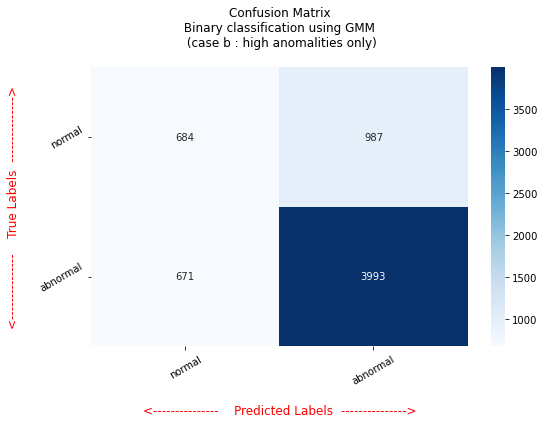

In [31]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_anomaly_test)

labeled_classes = ['normal', 'abnormal']
classes = [0+0.5, 1+0.5]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title("Confusion Matrix\n Binary classification using GMM \n (case b : high anomalities only)\n")
plt.tight_layout()
plt.show()